#Libraries & Data Loading

In [2]:
#Connecting to drive:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd /content/drive/MyDrive/BARQ/

/content/drive/MyDrive/BARQ


In [4]:
#Libraries Loading
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

#Exploratory Data Analysis (EDA)


##Data Loading & Initial Exploration

In [69]:
#Loading the CSV file
df = pd.read_csv('fifa_eda.csv')
df.head()

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,International Reputation,Skill Moves,Position,Joined,Contract Valid Until,Height,Weight,Release Clause
0,158023,L. Messi,31,Argentina,94,94,FC Barcelona,110500.0,565.0,Left,5.0,4.0,RF,2004,2021-01-01,5.583333,159.0,226500.0
1,20801,Cristiano Ronaldo,33,Portugal,94,94,Juventus,77000.0,405.0,Right,5.0,5.0,ST,2018,2022-01-01,6.166667,183.0,127100.0
2,190871,Neymar Jr,26,Brazil,92,93,Paris Saint-Germain,118500.0,290.0,Right,5.0,5.0,LW,2017,2022-01-01,5.750000,150.0,228100.0
3,193080,De Gea,27,Spain,91,93,Manchester United,72000.0,260.0,Right,4.0,1.0,GK,2011,2020-01-01,6.333333,168.0,138600.0
4,192985,K. De Bruyne,27,Belgium,91,92,Manchester City,102000.0,355.0,Right,4.0,4.0,RCM,2015,2023-01-01,5.916667,154.0,196400.0


In [70]:
df.shape

(18207, 18)

In [71]:
df.columns

Index(['ID', 'Name', 'Age', 'Nationality', 'Overall', 'Potential', 'Club',
       'Value', 'Wage', 'Preferred Foot', 'International Reputation',
       'Skill Moves', 'Position', 'Joined', 'Contract Valid Until', 'Height',
       'Weight', 'Release Clause'],
      dtype='object')

In [72]:
#Summary of the numeric variables
numeric_cols = df[['Age','Overall', 'Potential', 'Value', 'Wage', 'Height', 'Weight', 'Release Clause']]
numeric_cols.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,18207.0,25.122206,4.669943,16.000000,21.00,25.000000,28.000000,45.00
Overall,18207.0,66.238699,6.908930,46.000000,62.00,66.000000,71.000000,94.00
Potential,18207.0,71.307299,6.136496,48.000000,67.00,71.000000,75.000000,95.00
Value,17955.0,2444.530214,5626.715434,10.000000,325.00,700.000000,2100.000000,118500.00
Wage,18207.0,9.731312,21.999290,0.000000,1.00,3.000000,9.000000,565.00
Height,18207.0,5.946771,0.220514,5.083333,5.75,5.916667,6.083333,6.75
Weight,18207.0,165.979129,15.572775,110.000000,154.00,165.000000,176.000000,243.00
Release Clause,18207.0,4585.060971,10630.414430,13.000000,570.00,1300.000000,4585.060806,228100.00


In [73]:
#Checking data types for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18207 entries, 0 to 18206
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        18207 non-null  int64  
 1   Name                      18207 non-null  object 
 2   Age                       18207 non-null  int64  
 3   Nationality               18207 non-null  object 
 4   Overall                   18207 non-null  int64  
 5   Potential                 18207 non-null  int64  
 6   Club                      17966 non-null  object 
 7   Value                     17955 non-null  float64
 8   Wage                      18207 non-null  float64
 9   Preferred Foot            18207 non-null  object 
 10  International Reputation  18159 non-null  float64
 11  Skill Moves               18159 non-null  float64
 12  Position                  18207 non-null  object 
 13  Joined                    18207 non-null  int64  
 14  Contra

###Comments
- Columns `International Reputation`, `Skill Moves ` data types to int - OR keep as is
- Column `Contract Valid Until ` data type to datetime.


##Data Cleaning

###Checking Duplicate Values

In [74]:
df.duplicated().sum()
#No duplicate values!

np.int64(0)

###Checking nulls

In [75]:
df.isnull().sum()

,0
ID,0
Name,0
Age,0
Nationality,0
Overall,0
Potential,0
Club,241
Value,252
Wage,0
Preferred Foot,0


In [76]:
#Exploring the data to detect if these nulls made by a special event/ feature
df.loc[df['International Reputation'].isnull()].head()

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,International Reputation,Skill Moves,Position,Joined,Contract Valid Until,Height,Weight,Release Clause
13236,177971,J. McNulty,33,Scotland,62,62,Rochdale,120.0,1.0,Right,NaN,NaN,LB,2016,NaN,5.946771,165.979129,4585.060806
13237,195380,J. Barrera,29,Nicaragua,62,62,Boyacá Chicó FC,300.0,1.0,Right,NaN,NaN,LB,2016,NaN,5.946771,165.979129,4585.060806
13238,139317,J. Stead,35,England,62,62,Notts County,140.0,3.0,Right,NaN,NaN,LB,2016,NaN,5.946771,165.979129,4585.060806
13239,240437,A. Semprini,20,Italy,62,72,Brescia,425.0,1.0,Right,NaN,NaN,LB,2016,NaN,5.946771,165.979129,4585.060806
13240,209462,R. Bingham,24,England,62,66,Hamilton Academical FC,400.0,1.0,Right,NaN,NaN,LB,2016,NaN,5.946771,165.979129,4585.060806


In [77]:
df.loc[df['Joined'] == 2016].head()

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,International Reputation,Skill Moves,Position,Joined,Contract Valid Until,Height,Weight,Release Clause
14,215914,N. Kanté,27,France,89,90,Chelsea,63000.0,225.0,Right,3.0,2.0,LDM,2016,2023-01-01,5.500000,159.0,121300.000000
28,198710,J. Rodríguez,26,Colombia,88,89,FC Bayern München,69500.0,315.0,Left,4.0,4.0,LAM,2016,2019-06-30,5.916667,172.0,4585.060806
34,178603,M. Hummels,29,Germany,88,88,FC Bayern München,46000.0,160.0,Right,4.0,3.0,LCB,2016,2021-01-01,6.250000,203.0,75900.000000
38,167664,G. Higuaín,30,Argentina,88,88,Milan,57000.0,245.0,Right,4.0,3.0,LS,2016,2019-06-30,6.083333,196.0,4585.060806
42,205600,S. Umtiti,24,France,87,92,FC Barcelona,57000.0,205.0,Left,3.0,2.0,CB,2016,2023-01-01,6.000000,165.0,121100.000000


### Adjusting the targeted columns data type:

In [78]:
#Note: after cleaning NAs, we can convert the float to int
df['Contract Valid Until'] = pd.to_datetime(df['Contract Valid Until'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18207 entries, 0 to 18206
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   ID                        18207 non-null  int64         
 1   Name                      18207 non-null  object        
 2   Age                       18207 non-null  int64         
 3   Nationality               18207 non-null  object        
 4   Overall                   18207 non-null  int64         
 5   Potential                 18207 non-null  int64         
 6   Club                      17966 non-null  object        
 7   Value                     17955 non-null  float64       
 8   Wage                      18207 non-null  float64       
 9   Preferred Foot            18207 non-null  object        
 10  International Reputation  18159 non-null  float64       
 11  Skill Moves               18159 non-null  float64       
 12  Position          

##Data Visualization
###Univariate Analysis: Visualizing key variables

In [79]:
df.columns

Index(['ID', 'Name', 'Age', 'Nationality', 'Overall', 'Potential', 'Club',
       'Value', 'Wage', 'Preferred Foot', 'International Reputation',
       'Skill Moves', 'Position', 'Joined', 'Contract Valid Until', 'Height',
       'Weight', 'Release Clause'],
      dtype='object')

###Numerical Variables
`Age`
`Overall`
`Potential`
`Value`
`Wage`
`Height`
`Weight`
`Release Clause`

- Histograms
- Boxplots
- countplots

In [113]:
#Function to Plot Histograms given the dataframe and the column name:
def Histogram(df, col):
  df_Histogram = df[col]

  plt.figure(figsize= (10,6))
  sns.histplot(df_Histogram, bins = 50, kde= True, color= 'orchid')
  plt.xlabel(f'{col}')
  plt.ylabel('Frequency')
  plt.title(f'Histogram of {col} Column')

  plt.show()

In [114]:
#Function to Plot Boxplots given the dataframe and the column name:
def Boxplot(df, col):
  df_Boxplot = df[col]

  plt.figure(figsize=(6, 4))
  sns.boxplot(x=df[col], color = 'orange')
  plt.title(f'Boxplot of {col} Column', fontsize=14)
  plt.xlabel(f'{col}')

  plt.show()

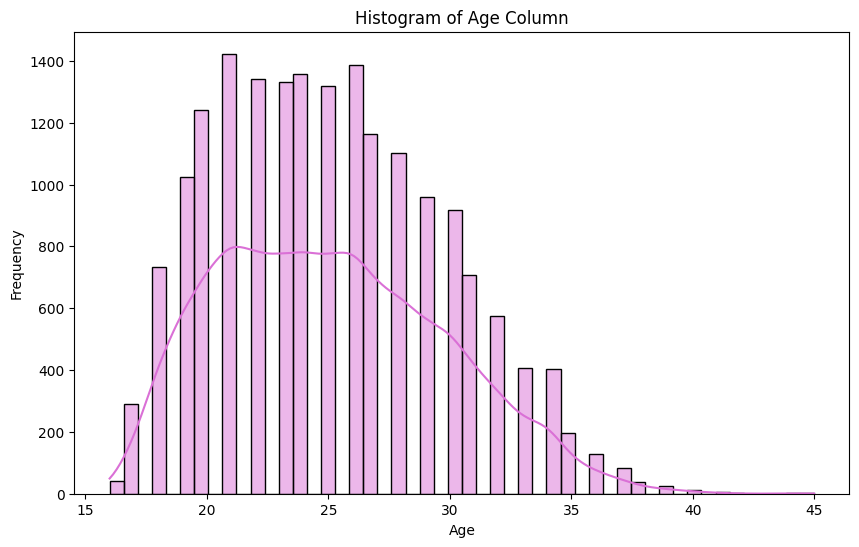

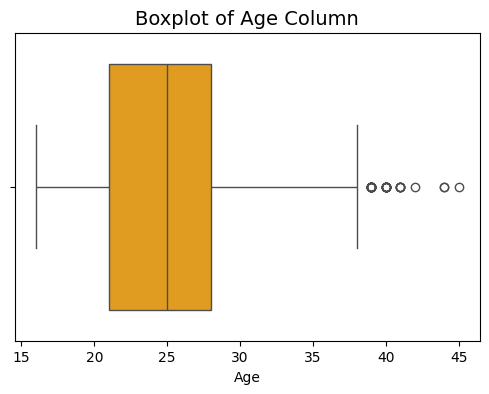

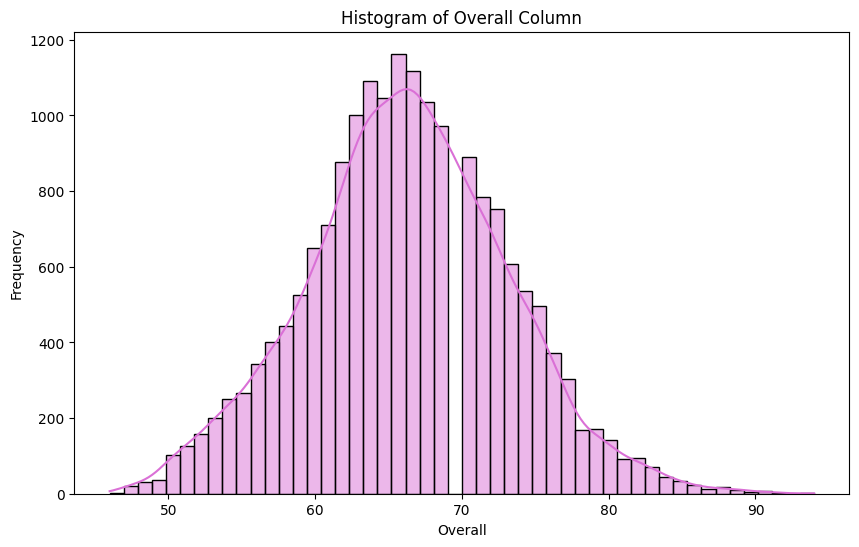

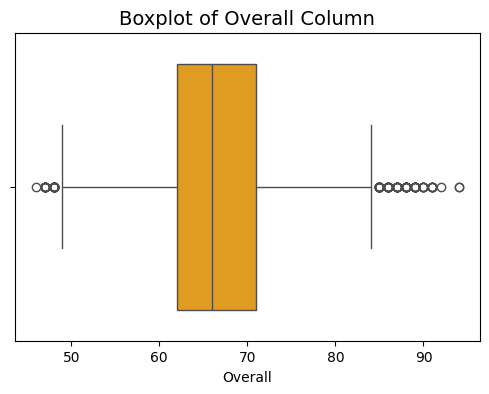

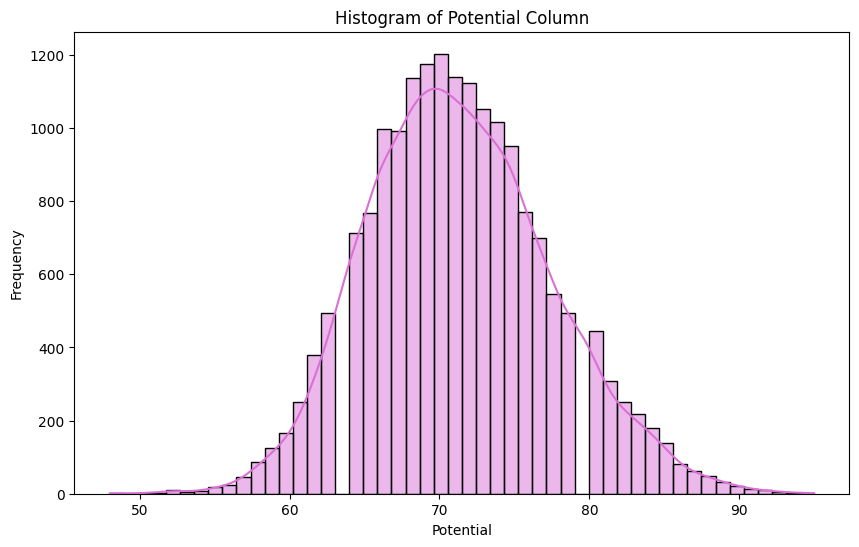

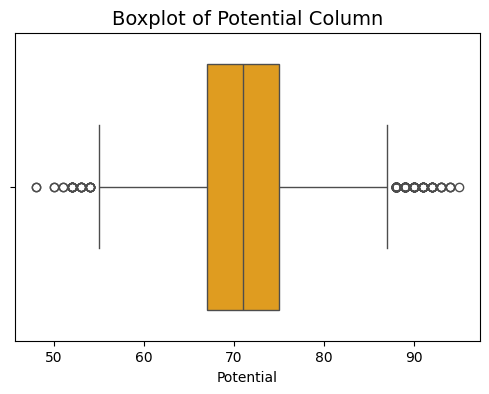

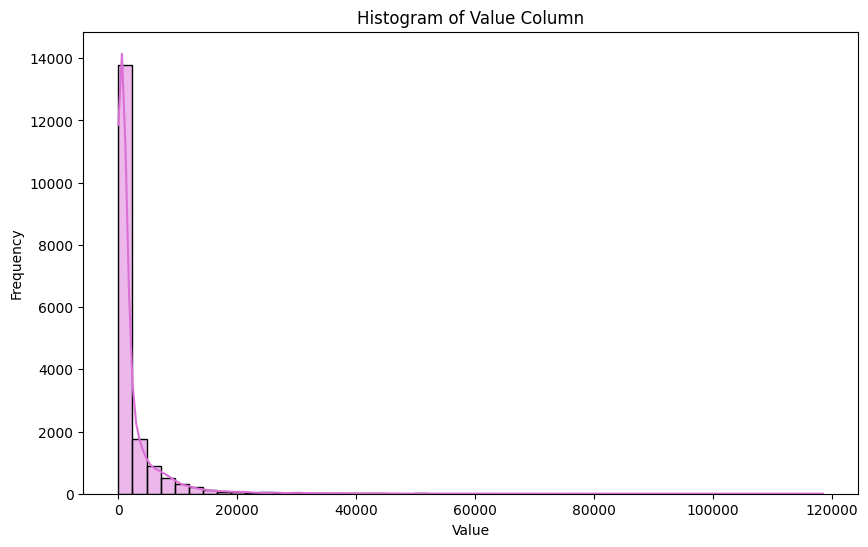

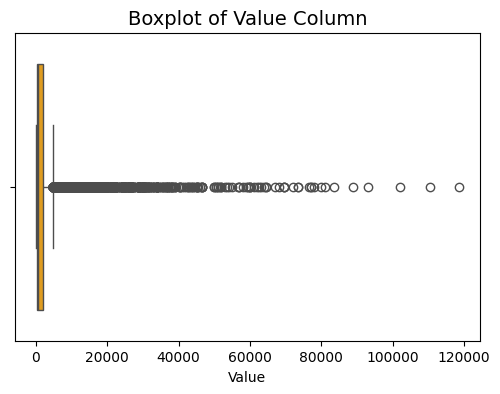

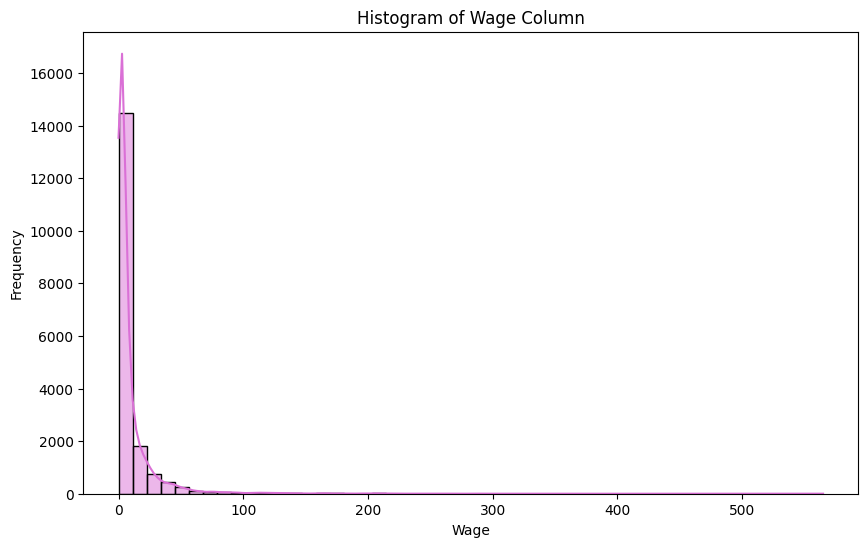

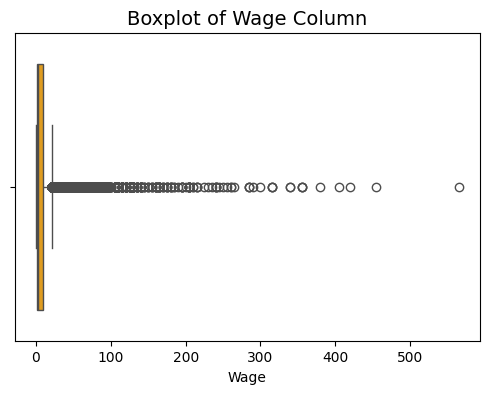

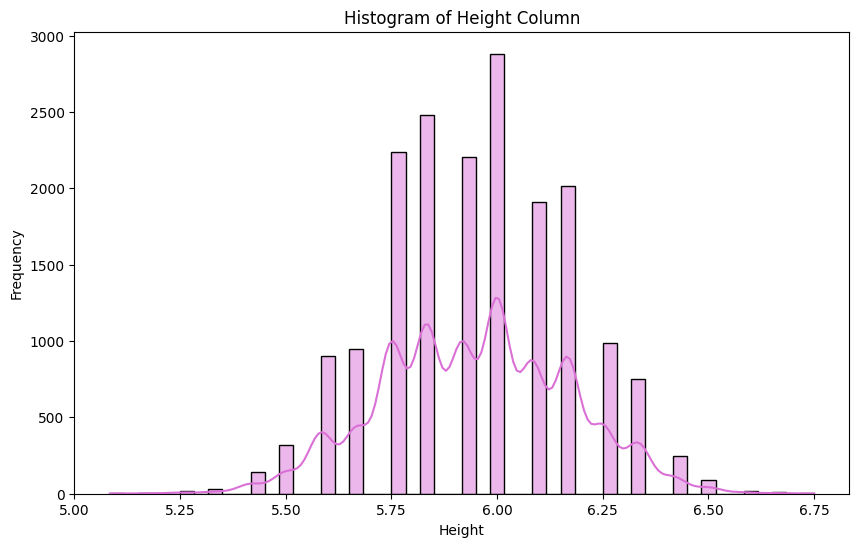

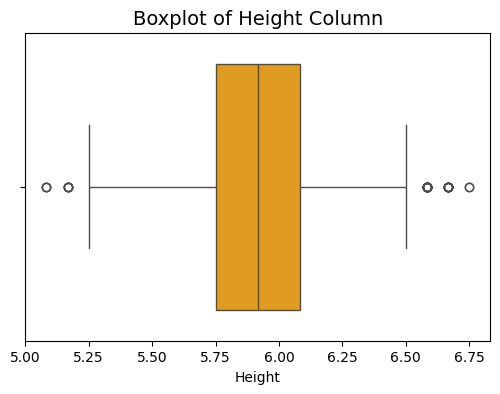

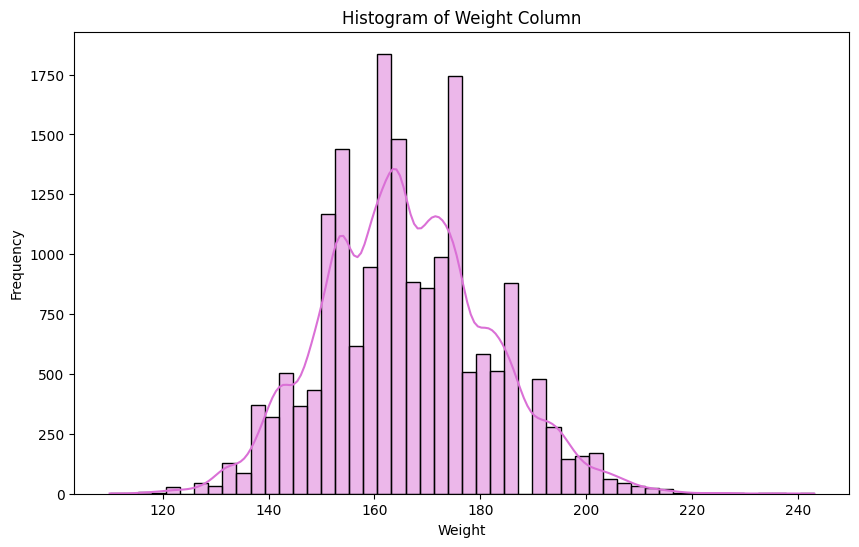

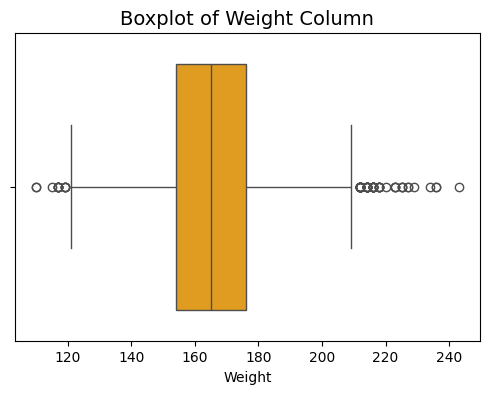

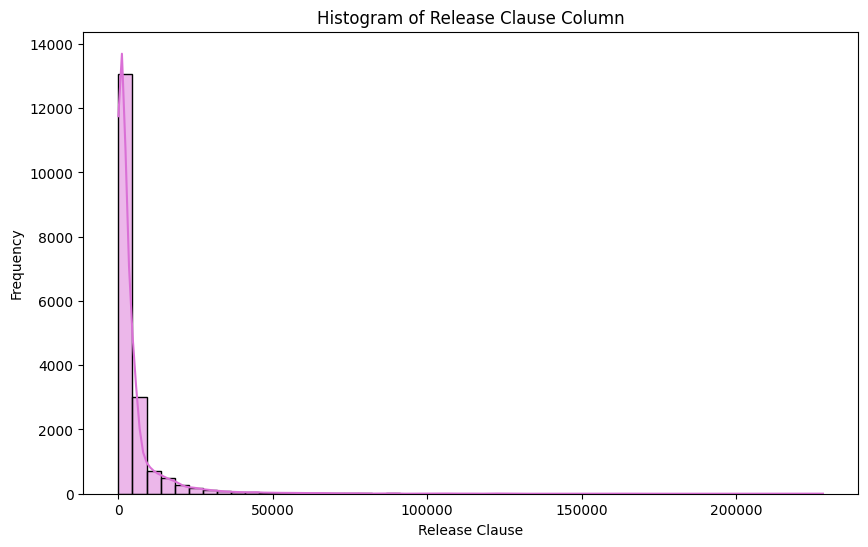

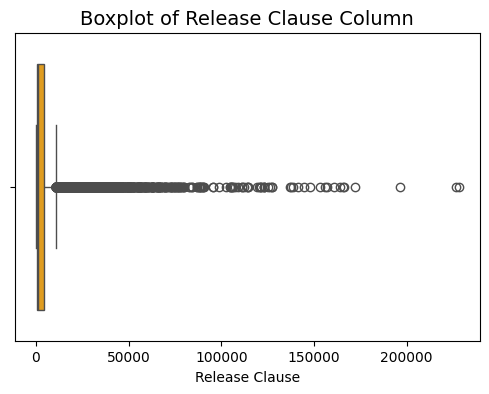

In [ ]:
#Barchart of Numerical Variables:
numerical_cols = ['Age', 'Overall', 'Potential', 'Value', 'Wage','Height', 'Weight', 'Release Clause']
for col in numerical_cols:
  Histogram(df, col)
  Boxplot(df, col)

###Comments:
- Variables `Age`, `Weight`, `Height`, `Potential`, `Overall` have normal distribution & some (not many outliers).
- Variables `Release Column`, `Wage`, `Value` are skewed to the right.
- Variables `Release Column`, `Wage`, `Value` have many outliers & may need feature scaling for future ML purposes.

In [ ]:
#Function to Plot Countplots given the dataframe and the column names:
def Countplot(df, col, hue):
  plt.figure(figsize=(12, 6))
  sns.countplot(x=col, hue= hue, data=df, palette = 'colorblind')
  plt.title(f'Countplot of {col} and {hue} Columns')
  plt.xlabel(f'{col}')
  plt.ylabel('Count')
  plt.legend(title=f'{hue}')
  plt.show()


  ##NOT YET USED

###Categorical Variables

`Nationality`
`Preferred Foot`
`International Reputation`
`Skill Moves`
`Joined`
`Position`

- Barchart

In [91]:
#Function to Plot Barcharts given the dataframe and the column name:
def BarPlot(df, col):
  plt.figure(figsize=(10, 6))
  df_Barchart = df[col].value_counts().head(10)
  df_Barchart.plot(kind = 'bar', color= 'purple' )

  plt.title(f'Barchart of {col} Column',  fontsize= 16)
  plt.xlabel(f'{col}', fontsize= 14)
  plt.ylabel('Total Players', fontsize= 14)

  plt.show()

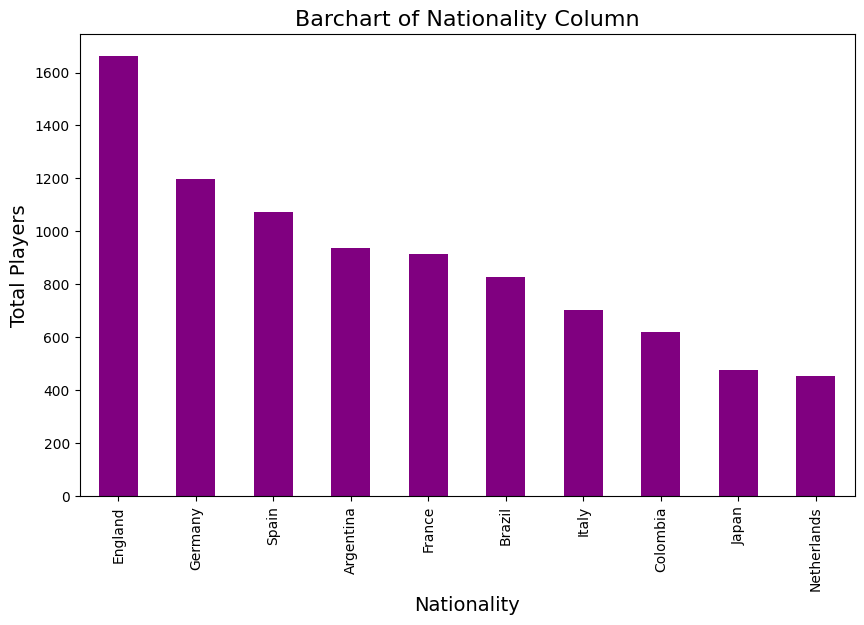

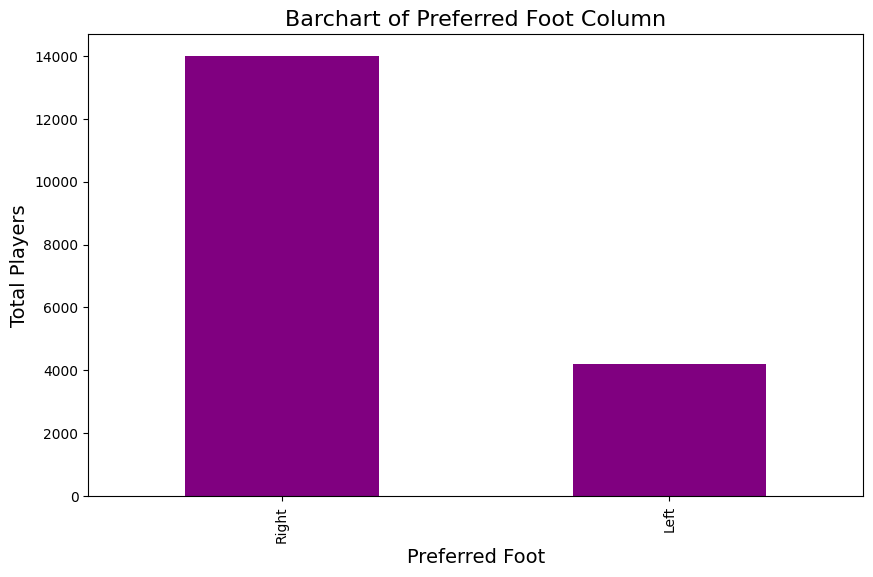

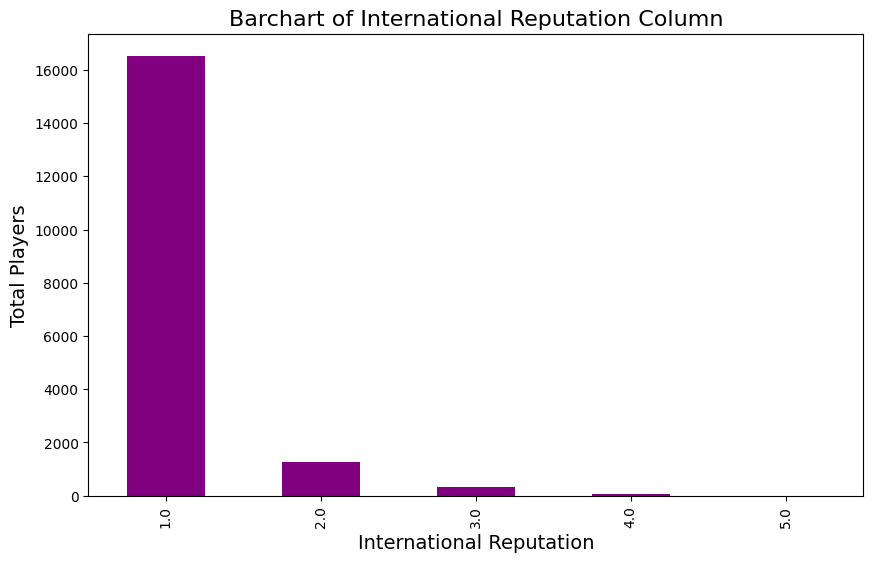

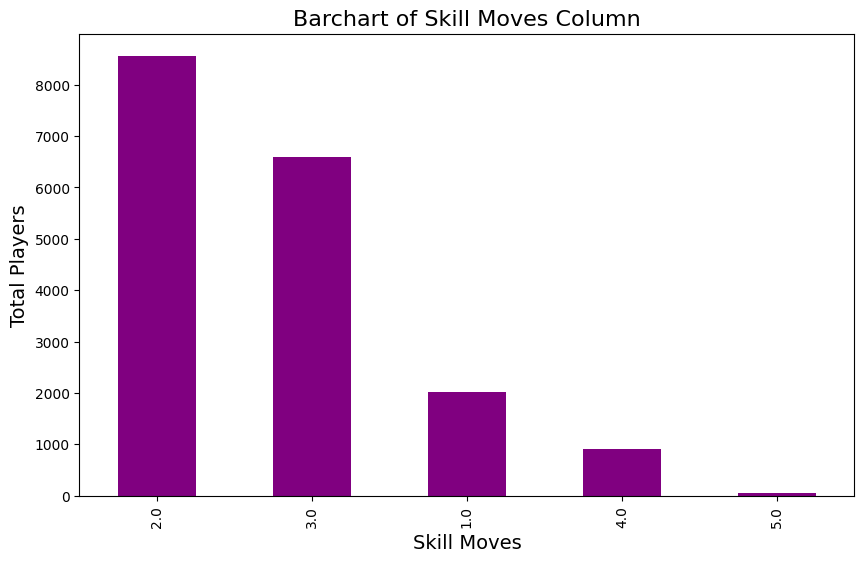

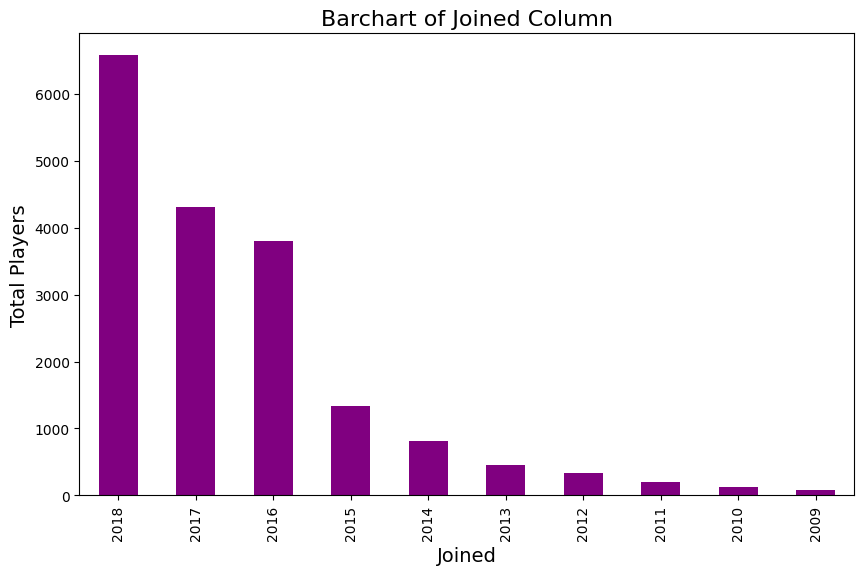

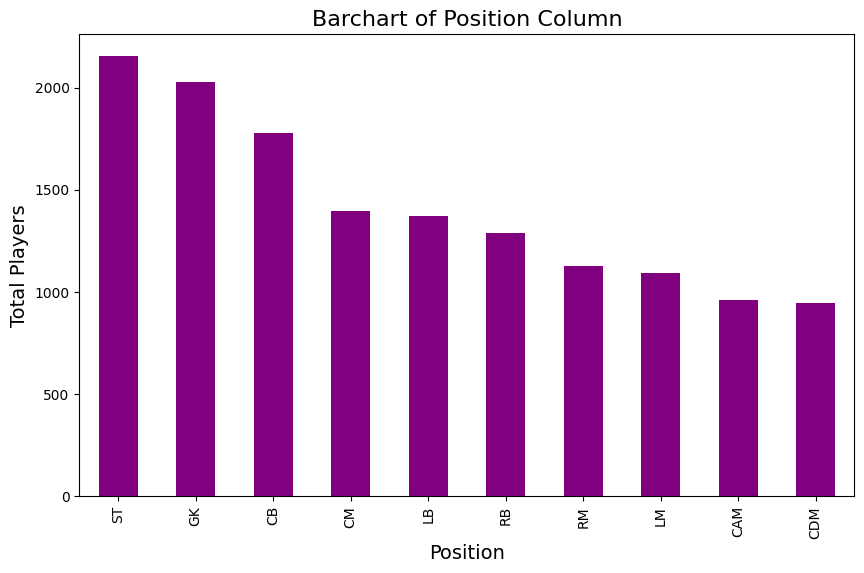

In [93]:
#Barchart of Categorical Variables:
categorical_cols = ['Nationality', 'Preferred Foot', 'International Reputation', 'Skill Moves', 'Joined', 'Position']
for col in categorical_cols:
  BarPlot(df, col)

###Bivariate Analysis: Visualizing relationships among variables:

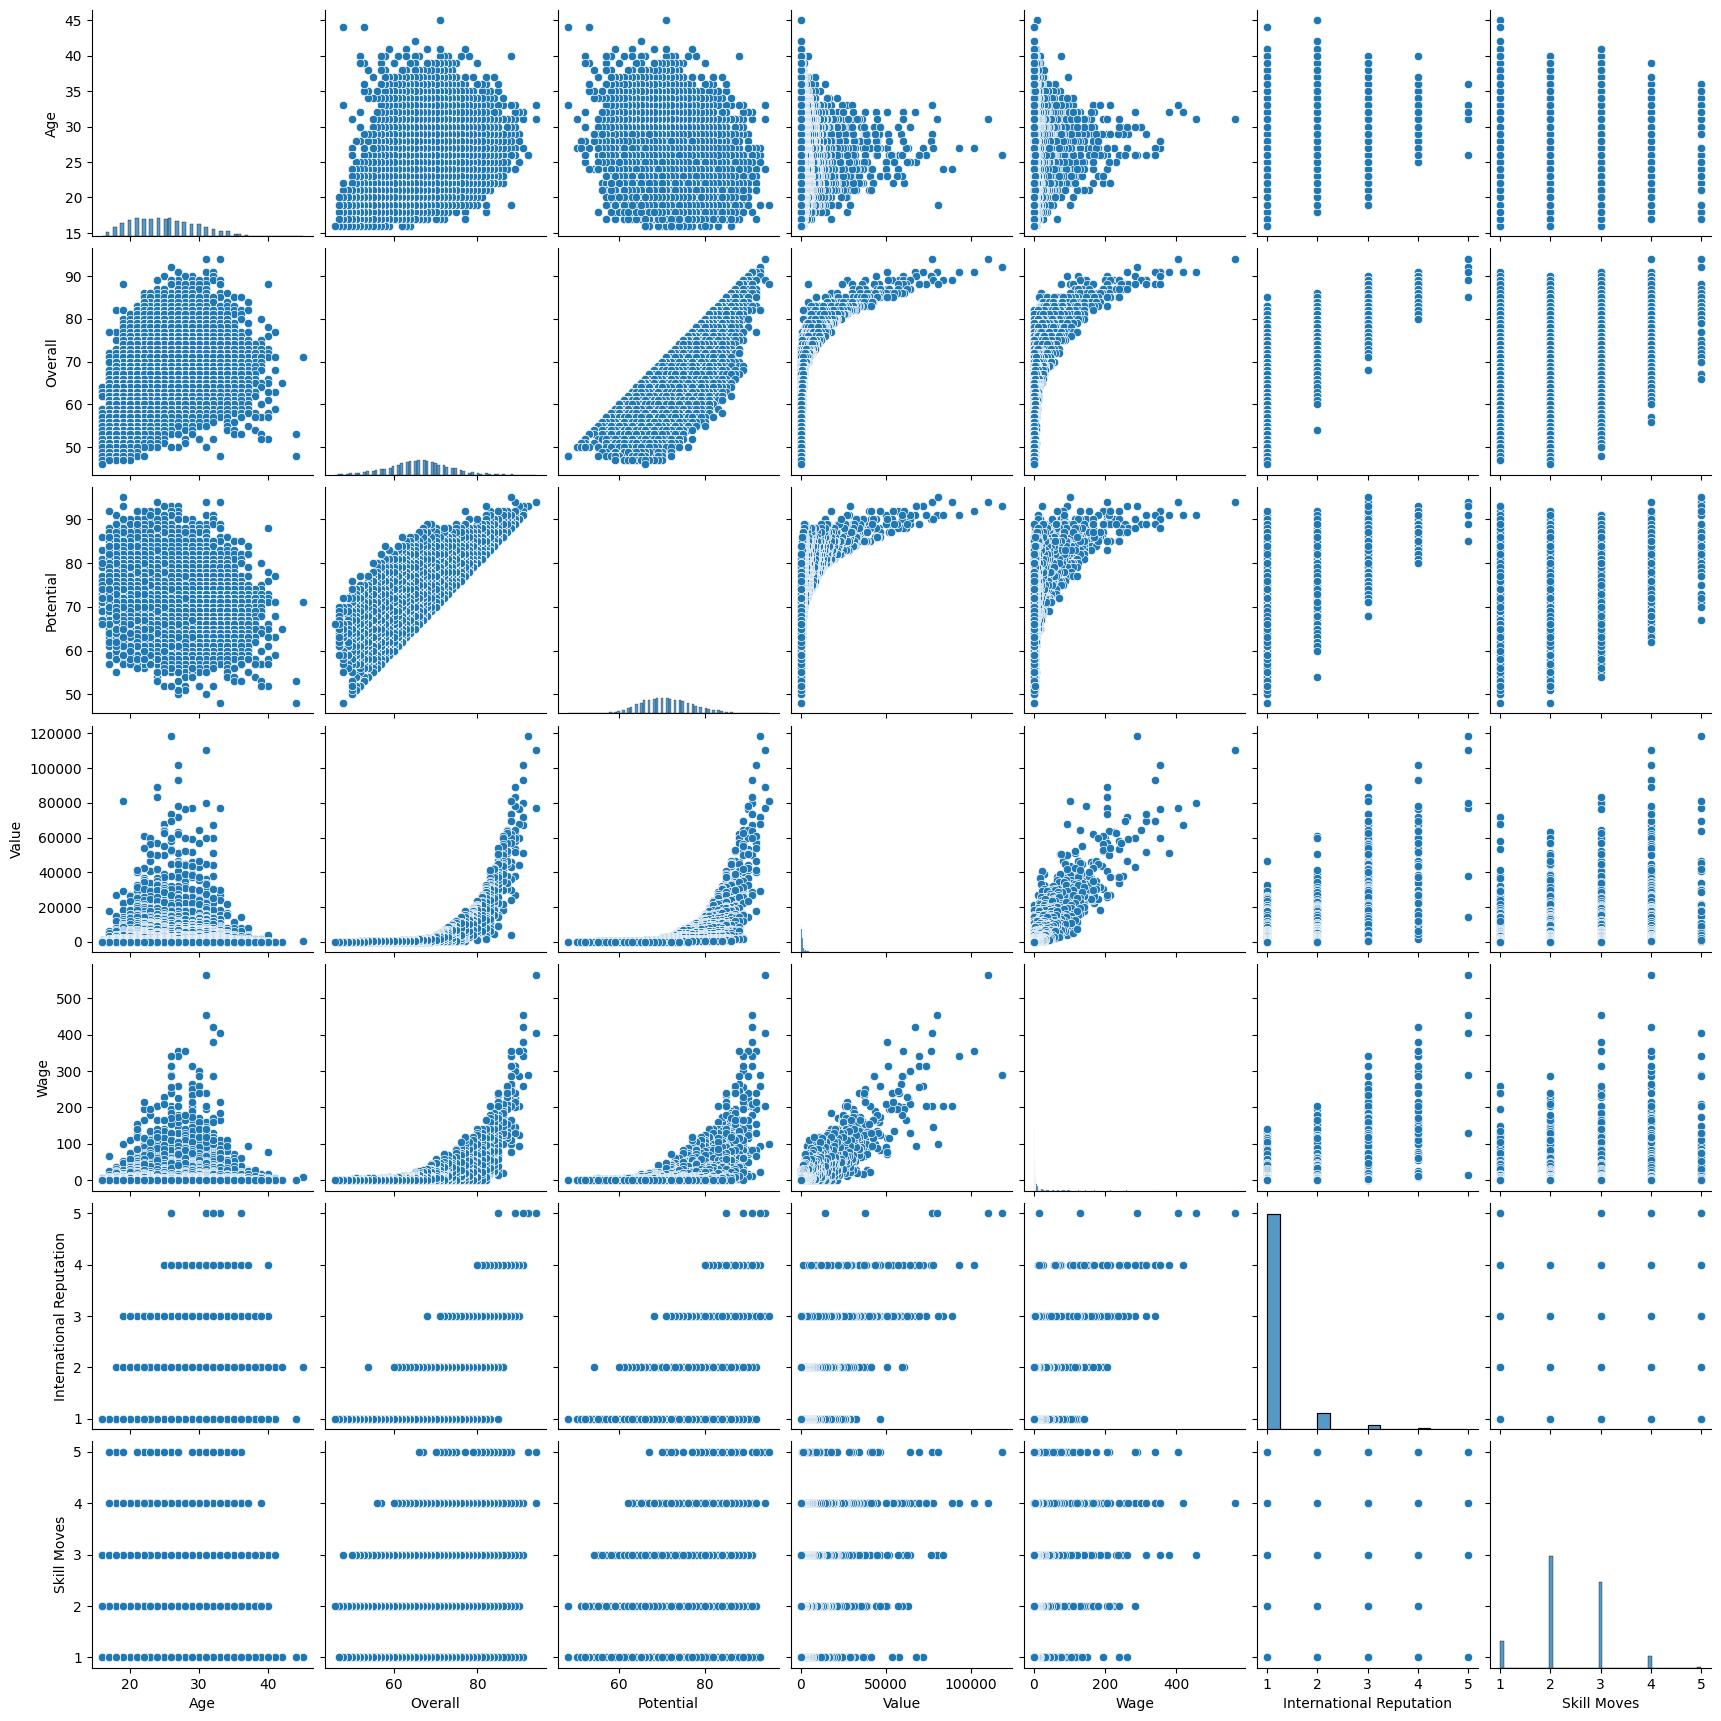

In [97]:
#Pairplots of numeric variables:
pairplot_cols = ['Age', 'Overall', 'Potential', 'Value', 'Wage',
                 'International Reputation', 'Skill Moves']

sns.pairplot(df[pairplot_cols])
plt.suptitle('Pairplot of Selected FIFA Player Attributes', y=1.02)
plt.show()

Text(0.5, 1.0, 'Top 10 Nationalities by Average Player Value')

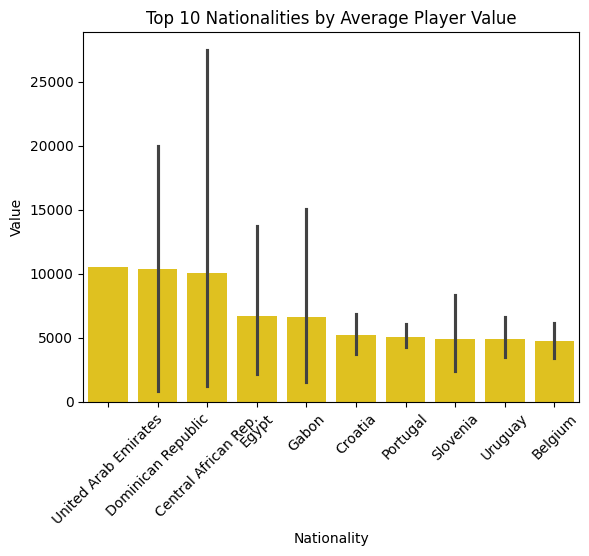

In [104]:
#Nationality vs Average Value
top_countries = df.groupby('Nationality')['Value'].mean().nlargest(10).index
sns.barplot(
    data=df[df['Nationality'].isin(top_countries)],
    x='Nationality',
    y='Value',
    order=df.groupby('Nationality')['Value'].mean().nlargest(10).index,
    color='gold'
)
plt.xticks(rotation=45)
plt.title('Top 10 Nationalities by Average Player Value')

Text(0.5, 1.0, 'Average Overall Rating by Preferred Foot')

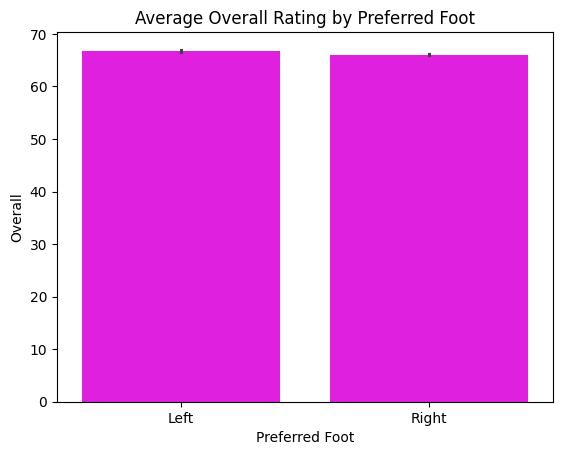

In [103]:
#Preferred Foot vs Average Overall Rating
sns.barplot(data=df, x='Preferred Foot', y='Overall', color= 'magenta')
plt.title('Average Overall Rating by Preferred Foot')

###Multivariate Analysis: Visualizing relationships among variables:

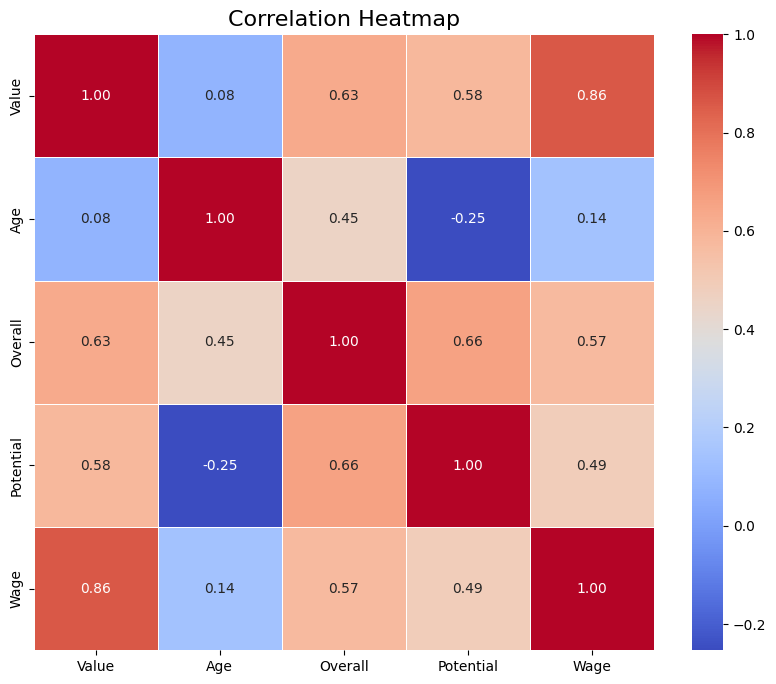

In [96]:
#Correlation Heatmap of Player Attributes
corr_matrix = df[['Value', 'Age', 'Overall', 'Potential', 'Wage']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Heatmap", fontsize=16)
plt.show()
#Insight: Highlights skill profiles by role.

##Outliers Detection

In [109]:
#Getting the Observation indices with extreme values/ outliers
columns_w_outliers = df[['Age', 'Overall', 'Potential', 'Value', 'Wage','Height', 'Weight', 'Release Clause']]
for col in columns_w_outliers:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  print(f'Outlier Indices in {col} column' + '\n')
  print(df[(df[col] < (Q1 - 1.5 * (Q3 - Q1))) | (df[col] > (Q3 + 1.5 * (Q3 - Q1)))].index)


Outlier Indices in Age column

Index([   41,   554,   864,  1120,  1294,  1952,  2225,  2706,  2821,  3128,
        3420,  3550,  3603,  4062,  4187,  4228,  4640,  4646,  4741,  5040,
        5101,  5608,  6398,  6861,  7039,  7225,  7427,  9484, 10356, 10487,
       10534, 10545, 11456, 12192, 12453, 14129, 14920, 15133, 15426, 16264,
       16489, 16596, 17672, 17726, 17752, 17842, 18183],
      dtype='int64')
Outlier Indices in Overall column

Index([    0,     1,     2,     3,     4,     5,     6,     7,     8,     9,
       ...
       18197, 18198, 18199, 18200, 18201, 18202, 18203, 18204, 18205, 18206],
      dtype='int64', length=163)
Outlier Indices in Potential column

Index([    0,     1,     2,     3,     4,     5,     6,     7,     8,     9,
       ...
       17988, 18017, 18025, 18043, 18052, 18055, 18067, 18074, 18171, 18183],
      dtype='int64', length=160)
Outlier Indices in Value column

Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
  